In [503]:
import geopandas as gpd
from matplotlib import font_manager
import matplotlib.pyplot as plt
# Find the path to the Arial font
arial_font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'  # Update this path based on your system

# Add the Arial font to the font manager
font_manager.fontManager.addfont(arial_font_path)

# Set the font to Arial
plt.rcParams['font.family'] = 'Arial'


In [527]:
points = gpd.read_file('/home/rene1337/RSCPH/landsat_tree_analysis/fmnr_full_village.gpkg')
areas = gpd.read_file('/home/rene1337/RSCPH/landsat_tree_analysis/fmnr_002_stats_v2.gpkg')

points_grouped = points.groupby('site_village').sum(numeric_only=True)

joined = points_grouped.merge(areas, on='site_village', how='left')

joined = joined.dropna(subset=['rel_abs_diff_sum', 'rel_abs_diff_mean'])

gdf = gpd.GeoDataFrame(joined, geometry='geometry')

In [451]:
drop_list = ['nbreplante_x',
 'nbregreffe_x',
 'lon_x',
 'lat_x',
 'fid',
 'ID',
 'pays',
 'zone',
 'site',
 'village',
 'hhid',
 'nomcheffamille',
 'statutCF_y',
 'sexeCF_y',
 'longitudedomicile',
 'latitudedomicile',
 'nomenqueteur',
 'jourenquete',
 'nbfemmes<16_y',
 'nbfemmes16_59_y',
 'nbfemmes>59_y',
 'nbhommes<16_y',
 'nbhommes16_59_y',
 'nbhommes>59_y',
 'taillemenage_y',
 'educationformelleCF_y',
 'educationnonformelleCF_y',
 'nombrevisitesvulgariateur_y',
 'participationprojet_y',
 'nomprojet',
 'annee adhesionprojet_y',
 'veterinaireauvillage',
 'typeveterinairevillage_y',
 'distanceposteveterinairePProche',
 'typeveterinaireproche_y',
 'boutique intrants au village_y',
 'typeboutique',
 'distancebtiqproche_y',
 'disponibiliteintrants_y',
 'accesscredit_y',
 'distanceaccesscredit_y',
 'dureecredit_y',
 'tauxannuel_y',
 'accessmarche_y',
 'produit1_mil_y',
 'produit2_sorgho_y',
 'produit3_riz_y',
 'produit4_fonio',
 'produit5_haricot_y',
 'distancemarcheproches1_y',
 'distancemarcheproches2_y',
 'Field47',
 'Field48',
 'Field49',
 'Field50',
 'statutCF_x',
 'sexeCF_x',
 'nbfemmes<16_x',
 'nbfemmes16_59_x',
 'nbfemmes>59_x',
 'nbhommes<16_x',
 'nbhommes16_59_x',
 'nbhommes>59_x',
 'taillemenage_x',
 'educationformelleCF_x',
 'educationnonformelleCF_x',
 'nombrevisitesvulgariateur_x',
 'participationprojet_x',
 'annee adhesionprojet_x',
 'typeveterinairevillage_x',
 'typeveterinaireproche_x',
 'boutique intrants au village_x',
 'distancebtiqproche_x',
 'disponibiliteintrants_x',
 'accesscredit_x',
 'distanceaccesscredit_x',
 'dureecredit_x',
 'tauxannuel_x',
 'accessmarche_x',
 'produit1_mil_x',
 'produit2_sorgho_x',
 'produit3_riz_x',
 'produit5_haricot_x',
 'distancemarcheproches1_x',
 'distancemarcheproches2_x',
 'numerochamp_x',
 'numparcelle_x',
 'statutCF_x',
 'sexeCF_x',
 'nbfemmes<16_x',
 'nbfemmes16_59_x',
 'nbfemmes>59_x',
 'nbhommes<16_x',
 'nbhommes16_59_x',
 'nbhommes>59_x',
 'taillemenage_x',
 'educationformelleCF_x',
 'educationnonformelleCF_x',
 'nombrevisitesvulgariateur_x',
 'participationprojet_x',
 'annee adhesionprojet_x',
 'typeveterinairevillage_x',
 'typeveterinaireproche_x',
 'boutique intrants au village_x',
 'distancebtiqproche_x',
 'disponibiliteintrants_x',
 'accesscredit_x',
 'distanceaccesscredit_x',
 'dureecredit_x',
 'tauxannuel_x',
 'accessmarche_x',
 'produit1_mil_x',
 'produit2_sorgho_x',
 'produit3_riz_x',
 'produit5_haricot_x',
 'distancemarcheproches1_x',
 'distancemarcheproches2_x',
 'numerochamp_x',
 'numparcelle_x',
 'numerochamp_y', 'numparcelle_y', 'nomesp_y',
       'nombrediam<10_y', 'nombrediam(10-20)_y', 'nombrediam(20-40)_y',
       'nombrediam(40-60)_y', 'nombrediam (>60)_y', 'totalnbrearbres_y',
       'nbreplante_y', 'nbregreffe_y', 'lon_y', 'lat_y',
  'fid_2', 'DN', 'area', 'perimeter', '_mean', '_min', 'region',
       'country', 'country_region',
 ]

In [452]:
gdf.drop(columns=drop_list, inplace=True)

In [508]:
gdf = gdf.to_crs('EPSG:3857')

In [528]:
gdf['fmnr'] = gdf['totalnbrearbres_x'].apply(lambda x: 1 if x > 1000 else 0)
fmnr = gdf[gdf['fmnr'] == 1]
control = gdf[gdf['fmnr'] == 0]
print(len(fmnr), len(control))

20 5


T-statistic: 2.774, p-value: 0.0135


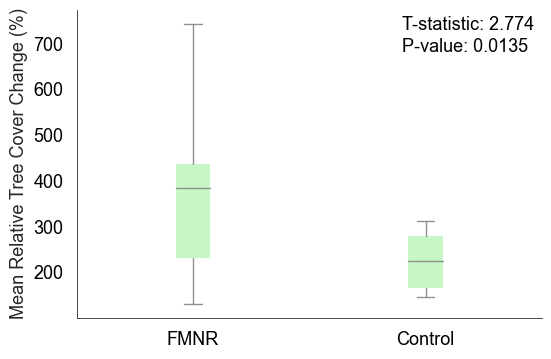

In [529]:
from tkinter import font
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(fmnr["rel_abs_diff_mean"], control["rel_abs_diff_mean"], equal_var=False)

print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

# ==== Box plot ====
fontsize = 13
fig, ax = plt.subplots(figsize=(6, 4))
plt.rcParams['font.family'] = 'Arial'
bp = ax.boxplot([fmnr["rel_abs_diff_mean"], control["rel_abs_diff_mean"]], labels=['FMNR', 'Control'], patch_artist=True)  # patch_artist=True allows filling with color

ax.text(0.7, 0.95, f"T-statistic: {t_stat:.3f}",
        transform=ax.transAxes, fontsize=fontsize, color='black', ha='left', va='center')

ax.text(0.7, 0.88, f"P-value: {p_val:.4f}",
        transform=ax.transAxes, fontsize=fontsize, color='black', ha='left', va='center')

# Change box fill color
colors = ["lightgreen"]  # green

for patch in bp['boxes']:
    patch.set_facecolor(colors[0])
    patch.set_alpha(0.5)  # Set transparency
    patch.set_edgecolor('none')

# Change whisker, cap, and median colors
for whisker in bp['whiskers']:
    whisker.set_color('grey')
    whisker.set_alpha(0.85)  # Set transparency
for cap in bp['caps']:
    cap.set_color('grey')
    cap.set_alpha(0.85)
for median in bp['medians']:
    median.set_color('grey')
    median.set_alpha(0.85)  # Set transparency
    
ax.set_ylabel('Mean Relative Tree Cover Change (%)', fontsize=fontsize)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)


# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5, labelsize=fontsize)
ax.tick_params(axis='y', colors='black', width = 0.5, labelsize=fontsize)
plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/fmnr_niger_boxplot.svg', bbox_inches='tight')



T-statistic: 1.922, p-value: 0.1001


/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


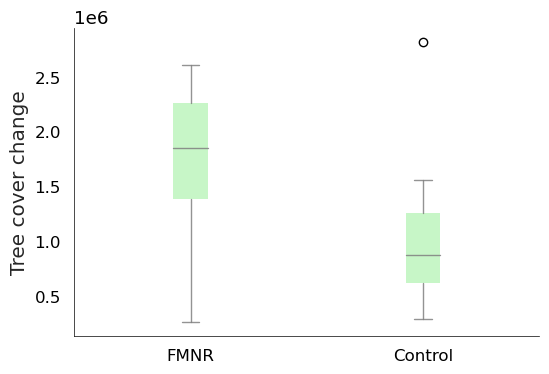

In [266]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

df = gdf1_2
# ==== Classify FMNR vs Control using K-means ====
X = df[['totalnbrearbres_x']].values
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)
df['cluster'] = kmeans.labels_

# High tree count cluster = FMNR
high_cluster = df.groupby('cluster')['totalnbrearbres_x'].mean().idxmax()
df['fmnr_class'] = np.where(df['cluster'] == high_cluster, 'FMNR', 'Control')

# ==== T-test between FMNR and Control for tree change ====
fmnr_change = df.loc[df['fmnr_class'] == 'FMNR', 'rel_abs_diff_sum']
control_change = df.loc[df['fmnr_class'] == 'Control', 'rel_abs_diff_sum']

t_stat, p_val = ttest_ind(fmnr_change, control_change, equal_var=False)

print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

# ==== Box plot ====
fig, ax = plt.subplots(figsize=(6, 4))

bp = ax.boxplot([fmnr_change, control_change], labels=['FMNR', 'Control'], patch_artist=True)  # patch_artist=True allows filling with color

# Change box fill color
colors = ["lightgreen"]  # green

for patch in bp['boxes']:
    patch.set_facecolor(colors[0])
    patch.set_alpha(0.5)  # Set transparency
    patch.set_edgecolor('none')

# Change whisker, cap, and median colors
for whisker in bp['whiskers']:
    whisker.set_color('grey')
    whisker.set_alpha(0.85)  # Set transparency
for cap in bp['caps']:
    cap.set_color('grey')
    cap.set_alpha(0.85)
for median in bp['medians']:
    median.set_color('grey')
    median.set_alpha(0.85)  # Set transparency
    
ax.set_ylabel('Tree cover change')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
fontsize=12

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5, labelsize=fontsize)
ax.tick_params(axis='y', colors='black', width = 0.5, labelsize=fontsize)

# color boxplot
for box in ax.artists:
    box.set_edgecolor('black')
    box.set_facecolor('lightgreen')
    box.set_linewidth(0.5)

plt.show()




In [512]:
fmnr = gpd.read_file('/home/rene1337/RSCPH/landsat_tree_analysis/fmnr_002_stats_v2.gpkg')
control = gpd.read_file('/home/rene1337/RSCPH/landsat_tree_analysis/fmnr_control_manual.gpkg')

print(len(fmnr), len(control))
fmnr = fmnr.dropna(subset=['rel_abs_diff_sum', 'abs_diff_sum','rel_abs_diff_mean', 'abs_diff_mean'])
control = control.dropna(subset=['rel_abs_diff_sum', 'abs_diff_sum','rel_abs_diff_mean', 'abs_diff_mean'])
print(len(fmnr), len(control))


25 25
25 22


T-statistic: 4.454, p-value: 0.0001


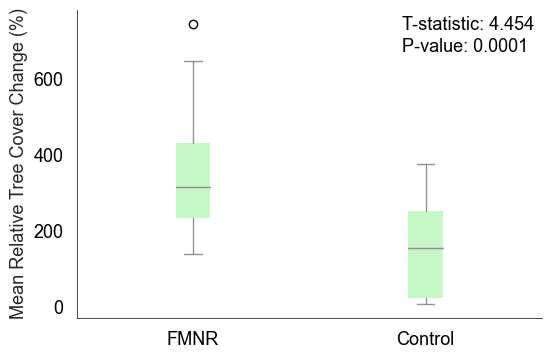

In [525]:
t_stat, p_val = ttest_ind(fmnr["pos_rel_mean"], control["pos_rel_abs_diff_mean"], equal_var=False)

print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")

# ==== Box plot ====
fontsize = 13
fig, ax = plt.subplots(figsize=(6, 4))
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Arial'

ax.text(0.7, 0.95, f"T-statistic: {t_stat:.3f}",
        transform=ax.transAxes, fontsize=fontsize, color='black', ha='left', va='center')

ax.text(0.7, 0.88, f"P-value: {p_val:.4f}",
        transform=ax.transAxes, fontsize=fontsize, color='black', ha='left', va='center')

bp = ax.boxplot([fmnr["pos_rel_mean"], control["pos_rel_abs_diff_mean"]], labels=['FMNR', 'Control'], patch_artist=True)  # patch_artist=True allows filling with color

# Change box fill color
colors = ["lightgreen"]  # green

for patch in bp['boxes']:
    patch.set_facecolor(colors[0])
    patch.set_alpha(0.5)  # Set transparency
    patch.set_edgecolor('none')

# Change whisker, cap, and median colors
for whisker in bp['whiskers']:
    whisker.set_color('grey')
    whisker.set_alpha(0.85)  # Set transparency
for cap in bp['caps']:
    cap.set_color('grey')
    cap.set_alpha(0.85)
for median in bp['medians']:
    median.set_color('grey')
    median.set_alpha(0.85)  # Set transparency
    
ax.set_ylabel('Mean Relative Tree Cover Change (%)', fontsize=fontsize)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5, labelsize=fontsize)
ax.tick_params(axis='y', colors='black', width = 0.5, labelsize=fontsize)

plt.savefig('/home/rene1337/RSCPH/landsat_tree_analysis/fmnr_Sahel_boxplot.svg', bbox_inches='tight')


In [300]:
pd.read_csv('/mnt/sdd/downloads_on_drive_d/fmnr_control.csv')

,nbr,Country,refyear,comment,remark,Agrofor_practice,Type,Source,Location,Coordinates,Unique_location,tree_species,non_tree_species,sapling_surv_rates,shade_index,tree_density,unit_tree_density,spacing_btw_trees,spacing_unit
0,147,Senegal,2020.0,NaN,NaN,windbreaks; tree belt for sand dune fixation,forest,https://qcat.wocat.net/en/wocat/technologies/v...,"Lompoul, Departement de Kébémer","-16.6699, 15.4413",nn,nn,nn,NaN,NaN,NaN,NaN,NaN,NaN
1,76,Ghana,2017.0,NaN,NaN,Intercropping,cropped,"Akoto, D. S. / Partey, S. T. / Denich, M. / Kw...","Jeduako, Sekyere Central District, Ghana","06°55' and 07°30'N, 05°00'W",Characteristic features of both forest and sav...,Bambusa balcooa,"maize, cassava, cowpea",NaN,NaN,NaN,NaN,5 x 5,m
2,151,Togo,2020.0,NaN,NaN,culture en couloir,mixed,https://qcat.wocat.net/en/wocat/technologies/v...,"Atéda, Kara","1.226, 9.583",nn,"Leucaena sp, Cajanus cajan, Cassia siamea, Alb...",nn,NaN,NaN,NaN,NaN,NaN,NaN
3,152,Togo,2020.0,NaN,NaN,"Shelterbelt, windbreaks",mixed,https://qcat.wocat.net/en/wocat/technologies/v...,"Tchitchao, Kara","1.226, 9.583",nn,nn,nn,NaN,NaN,NaN,NaN,NaN,NaN
4,144,Niger,2020.0,NaN,NaN,Agro-silvopastoralism; Fixation des dunes sur ...,"cropped, pastoral",https://qcat.wocat.net/en/wocat/technologies/v...,"Communes rurales de Bouné, Kellé, Guidiguir, l...","10.26336, 14.00252\n12.00309, 13.30223\n11.140...",nn,"dates, mango, mangosteen, guava",nn,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,286,Ghana,2012.0,Heavy shade,NaN,shade trees,cropped,"Nunoo, I. / Owusu, V. 2017. Comparative analys...",Sefwi-Wiawso District,"6°00′-6°30 N, 2°15′-2°45 W",nn,cocoa,nn,NaN,NaN,NaN,NaN,NaN,NaN
73,438,Ethiopia,2007.0,NaN,NaN,nn,nn,"Temesgen, H. / Wu, W. / Shi, X. / Yirsaw, E. /...",Gedeo-Abaya,"6°09'02''-6°35'56''N, 38°00'01''E",nn,nn,nn,NaN,NaN,NaN,NaN,NaN,NaN
74,69,Nigeria,2009.0,unclear if it is alley cropping with groundnut...,NaN,Alley cropping,cropped,"Adinya, I. B. / Enun, E. E. / Ijoma, J. U. 201...","Abouchiche, Gakem, Ibiaragidi in Bekwarra Loca...",6°40'N 8°45'E,nn,Leucaena leucocephala,Arachis hypogaea,NaN,NaN,NaN,NaN,10 or 30 or 60,cm
75,145,Niger,2020.0,NaN,NaN,Windbreaks; Sand dune stabilisation,"cropped, pastoral",https://qcat.wocat.net/en/wocat/technologies/v...,Niger,"8.08864, 17.61131",nn,"Leptadenia pyrotechnica, Euphorbia balsamifera...",nn,NaN,NaN,NaN,NaN,NaN,NaN
